# PyTreeArrayDistribution Tutorial

`PyTreeArrayDistribution[T]` sits between `Distribution[T]` and `ArrayDistribution` in ProbPipe's hierarchy. It adds:

- **Pytree structure** (`treedef`) — the tree layout of a single sample.
- **Shape semantics** — `batch_shape`, per-leaf `event_shapes`, `flat_event_shapes`, `event_size`.
- **Flatten/unflatten** — lossless conversion between pytree values and flat vectors.
- **Flat-view interop** — `as_flat_distribution()` wraps any pytree distribution as a standard `ArrayDistribution`.

Existing `ArrayDistribution`s (Normal, MVN, Wishart, etc.) automatically inherit the pytree interface as a trivial single-leaf case. This notebook starts with a brief review of that case and then focuses on the more interesting **multi-leaf** case: distributions whose samples are dictionaries (or other pytrees) of arrays.

## The Distribution Hierarchy

ProbPipe's distribution classes form a three-level hierarchy:

```
Distribution[T]                  — generic base (sampling + optional log_prob)
  └── PyTreeArrayDistribution[T] — pytree structure, shapes, flatten/unflatten
        └── ArrayDistribution     — single-array specialization (T = Array)
              └── TFPDistribution  — delegates to tfd.* (Normal, Gamma, MVN, ...)
```

Every concrete distribution is an instance of all three base classes.

In [1]:
import math
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probpipe import (
    Distribution, PyTreeArrayDistribution, ArrayDistribution,
    FlattenedView, Normal, MultivariateNormal, Gamma, Wishart,
    EmpiricalDistribution, Provenance, real, positive, positive_definite,
    monte_carlo, BootstrapDistribution,
)
from probpipe import log_prob, mean, sample, variance

key = jax.random.PRNGKey(0)

## Quick Review: Single-Leaf (ArrayDistribution) Case

For `ArrayDistribution` subclasses, the pytree has a single leaf — the array itself. The Wishart distribution is a good example because its `event_shape=(d, d)` makes flatten/unflatten non-trivial (unlike MVN where events are already flat vectors).

In [2]:
w = Wishart(df=5.0, scale=jnp.eye(3))
print(f"Wishart: event_shape={w.event_shape}, event_size={w.event_size}")
print(f"  treedef           = {w.treedef}")
print(f"  flat_event_shapes = {w.flat_event_shapes}")

# Single sample: (3, 3) matrix → (9,) vector
s = sample(w, key=jax.random.PRNGKey(1))
flat = w.flatten_value(s)
print(f"\nSingle s:   {s.shape} → flatten → {flat.shape}")
print(f"Roundtrip match: {bool(jnp.allclose(s, w.unflatten_value(flat)))}")

# With sample_shape
samples = sample(w, key=jax.random.PRNGKey(2), sample_shape=(50,))
flat_batch = w.flatten_value(samples)
print(f"\nsample_shape=(50,): {samples.shape} → {flat_batch.shape}")

# With sample_shape AND batch_shape
w_batched = Wishart(df=jnp.array([5.0, 8.0]), scale=jnp.stack([jnp.eye(3), 2*jnp.eye(3)]))
print(f"\nBatched Wishart: batch_shape={w_batched.batch_shape}, event_shape={w_batched.event_shape}")
samples_wb = sample(w_batched, key=jax.random.PRNGKey(3), sample_shape=(10, 4))
flat_wb = w_batched.flatten_value(samples_wb)
print(f"sample_shape=(10,4) + batch_shape=(2,): {samples_wb.shape} → {flat_wb.shape}")
print(f"Roundtrip match: {bool(jnp.allclose(samples_wb, w_batched.unflatten_value(flat_wb)))}")

Wishart: event_shape=(3, 3), event_size=9
  treedef           = PyTreeDef(None)
  flat_event_shapes = [(3, 3)]



Single sample:   (3, 3) → flatten → (9,)
Roundtrip match: True



sample_shape=(50,): (50, 3, 3) → (50, 9)

Batched Wishart: batch_shape=(2,), event_shape=(3, 3)


sample_shape=(10,4) + batch_shape=(2,): (10, 4, 2, 3, 3) → (10, 4, 2, 9)
Roundtrip match: True


## Defining a Multi-Leaf PyTreeArrayDistribution

The single-leaf case is straightforward. The real power of `PyTreeArrayDistribution` emerges when samples are **pytrees with multiple leaves** — for example, a dictionary `{"weights": array, "precision": matrix}`.

Below we define `LinearModelPrior`: a joint prior over the parameters of a Bayesian linear model. A sample is a dict with two keys:

- `"weights"` — a `d`-dimensional vector drawn from a `MultivariateNormal`
- `"precision"` — a `d × d` positive-definite matrix drawn from a `Wishart`

The two components are independent, so `log_prob` is the sum of the individual log-probs.

In [3]:
from probpipe.core.distribution import _auto_key

class LinearModelPrior(PyTreeArrayDistribution[dict]):
    """Joint prior: weights ~ MVN, precision ~ Wishart."""

    def __init__(self, weight_dist: MultivariateNormal, precision_dist: Wishart,
                 *, name: str | None = None):
        self._weight_dist = weight_dist
        self._precision_dist = precision_dist
        self._name = name
        # Build treedef from a prototype sample structure
        prototype = {"precision": jnp.zeros(()), "weights": jnp.zeros(())}
        self._treedef = jax.tree.structure(prototype)

    # -- pytree structure ---
    @property
    def treedef(self):
        return self._treedef

    # -- shape properties ---
    @property
    def batch_shape(self):
        return self._weight_dist.batch_shape

    @property
    def event_shapes(self):
        return {"precision": self._precision_dist.event_shape,
                "weights": self._weight_dist.event_shape}

    # -- sampling ---
    def _sample(self, key):
        k1, k2 = jax.random.split(key)
        return {"precision": self._precision_dist._sample(k1),
                "weights": self._weight_dist._sample(k2)}

    def sample(self, key=None, sample_shape=()):
        if key is None:
            key = _auto_key()
        k1, k2 = jax.random.split(key)
        return {"precision": self._precision_dist.sample(k1, sample_shape),
                "weights": self._weight_dist.sample(k2, sample_shape)}

    # -- log_prob ---
    def log_prob(self, value):
        return (self._weight_dist.log_prob(value["weights"])
                + self._precision_dist.log_prob(value["precision"]))

    @property
    def name(self):
        return self._name

    def __repr__(self):
        d = self._weight_dist.event_shape[0]
        return f"LinearModelPrior(d={d}, name={self._name!r})"

In [4]:
# Create a 3-dimensional linear model prior
d = 3
prior = LinearModelPrior(
    weight_dist=MultivariateNormal(loc=jnp.zeros(d), cov=jnp.eye(d)),
    precision_dist=Wishart(df=float(d + 2), scale=jnp.eye(d)),
    name="linear_model_prior",
)
print(prior)
print(f"  treedef:           {prior.treedef}")
print(f"  batch_shape:       {prior.batch_shape}")
print(f"  event_shapes:      {prior.event_shapes}")
print(f"  flat_event_shapes: {prior.flat_event_shapes}")
print(f"  event_size:        {prior.event_size}  (3 from weights + 9 from 3×3 matrix)")

# Draw a single sample — it's a dict!
s = sample(prior, key=jax.random.PRNGKey(10))
print(f"\nSample keys: {list(s.keys())}")
print(f"  weights shape:   {s['weights'].shape}")
print(f"  precision shape: {s['precision'].shape}")

LinearModelPrior(d=3, name='linear_model_prior')
  treedef:           PyTreeDef({'precision': *, 'weights': *})
  batch_shape:       ()
  event_shapes:      {'precision': (3, 3), 'weights': (3,)}
  flat_event_shapes: [(3, 3), (3,)]
  event_size:        12  (3 from weights + 9 from 3×3 matrix)



Sample keys: ['precision', 'weights']
  weights shape:   (3,)
  precision shape: (3, 3)


## Multi-Leaf Flatten and Unflatten

For a multi-leaf distribution, `flatten_value()` ravels each leaf's event dimensions and concatenates them in canonical leaf order (alphabetical for dicts). This maps a dict of heterogeneous arrays to a single flat vector.

`unflatten_value()` reverses the process: it splits the flat vector at the right offsets and reshapes each chunk back to its leaf's event shape.

In [5]:
# Single sample: dict → flat vector → dict
s = sample(prior, key=jax.random.PRNGKey(10))
flat = prior.flatten_value(s)
restored = prior.unflatten_value(flat)

print("Single-sample roundtrip:")
print(f"  Original:  dict with weights{s['weights'].shape}, precision{s['precision'].shape}")
print(f"  Flattened: {flat.shape}  (9 from precision + 3 from weights = 12)")
print(f"  Restored:  dict with weights{restored['weights'].shape}, precision{restored['precision'].shape}")
print(f"  Match:     weights={bool(jnp.allclose(s['weights'], restored['weights']))}, "
      f"precision={bool(jnp.allclose(s['precision'], restored['precision']))}")

print()

# Batched samples: sample_shape preserved
samples = sample(prior, key=jax.random.PRNGKey(11), sample_shape=(100,))
flat_batch = prior.flatten_value(samples)
restored_batch = prior.unflatten_value(flat_batch)
print("Batched roundtrip (sample_shape=(100,)):")
print(f"  weights: {samples['weights'].shape} → flat {flat_batch.shape} → {restored_batch['weights'].shape}")
print(f"  precision: {samples['precision'].shape} → flat {flat_batch.shape} → {restored_batch['precision'].shape}")
print(f"  Match: {bool(jnp.allclose(samples['weights'], restored_batch['weights']))}")

Single-sample roundtrip:
  Original:  dict with weights(3,), precision(3, 3)
  Flattened: (12,)  (9 from precision + 3 from weights = 12)
  Restored:  dict with weights(3,), precision(3, 3)
  Match:     weights=True, precision=True



Batched roundtrip (sample_shape=(100,)):
  weights: (100, 3) → flat (100, 12) → (100, 3)
  precision: (100, 3, 3) → flat (100, 12) → (100, 3, 3)
  Match: True


In [6]:
# 2D sample_shape
samples_2d = sample(prior, key=jax.random.PRNGKey(12), sample_shape=(4, 5))
flat_2d = prior.flatten_value(samples_2d)
restored_2d = prior.unflatten_value(flat_2d)
print("2D sample_shape=(4, 5):")
print(f"  weights:   {samples_2d['weights'].shape} → flat {flat_2d.shape} → {restored_2d['weights'].shape}")
print(f"  precision: {samples_2d['precision'].shape} → flat {flat_2d.shape} → {restored_2d['precision'].shape}")
print(f"  Match: {bool(jnp.allclose(samples_2d['weights'], restored_2d['weights']))}")

2D sample_shape=(4, 5):
  weights:   (4, 5, 3) → flat (4, 5, 12) → (4, 5, 3)
  precision: (4, 5, 3, 3) → flat (4, 5, 12) → (4, 5, 3, 3)
  Match: True


## Log-Prob

`log_prob` accepts a pytree-valued sample and returns a scalar (or batch of scalars). For our independent joint distribution, it sums the component log-probs.

In [7]:
s = sample(prior, key=jax.random.PRNGKey(13))
lp = log_prob(prior, s)
print(f"log_prob of a single sample: {float(lp):.4f}")

# Verify it equals the sum of component log-probs
lp_w = log_prob(prior._weight_dist, s["weights"])
lp_p = log_prob(prior._precision_dist, s["precision"])
print(f"  weights log_prob:   {float(lp_w):.4f}")
print(f"  precision log_prob: {float(lp_p):.4f}")
print(f"  sum:                {float(lp_w + lp_p):.4f}")
print(f"  match:              {bool(jnp.allclose(lp, lp_w + lp_p))}")

log_prob of a single sample: -18.6501
  weights log_prob:   -6.0609
  precision log_prob: -12.5892
  sum:                -18.6501
  match:              True


## FlattenedView for Multi-Leaf Distributions

`as_flat_distribution()` wraps `LinearModelPrior` as a flat `ArrayDistribution` with `event_shape=(12,)`. Sampling produces flat 12-vectors; `log_prob` unflattens internally before delegating. This allows any algorithm expecting flat arrays to work with our structured distribution.

In [8]:
flat_prior = prior.as_flat_distribution()
print(f"Type:        {type(flat_prior).__name__}")
print(f"event_shape: {flat_prior.event_shape}")
print(f"batch_shape: {flat_prior.batch_shape}")
print(f"repr:        {flat_prior}")

# Flat sampling
flat_s = sample(flat_prior, key=jax.random.PRNGKey(14))
print(f"\nFlat sample shape: {flat_s.shape}")
print(f"Flat sample:       {flat_s[:5]}... (first 5 of 12)")

# Log-prob consistency
s = sample(prior, key=jax.random.PRNGKey(15))
flat_s = prior.flatten_value(s)
lp_pytree = log_prob(prior, s)
lp_flat = log_prob(flat_prior, flat_s)
print(f"\nlog_prob (pytree):  {float(lp_pytree):.6f}")
print(f"log_prob (flat):    {float(lp_flat):.6f}")
print(f"Match: {bool(jnp.allclose(lp_pytree, lp_flat))}")

# Unflatten back to dict
restored = flat_prior.unflatten_sample(flat_s)
print(f"\nUnflattened keys: {list(restored.keys())}")
print(f"weights match:    {bool(jnp.allclose(s['weights'], restored['weights']))}")
print(f"precision match:  {bool(jnp.allclose(s['precision'], restored['precision']))}")

Type:        FlattenedView
event_shape: (12,)
batch_shape: ()
repr:        FlattenedView(base=LinearModelPrior, event_shape=(12,))

Flat sample shape: (12,)
Flat sample:       [ 1.8788002  -0.319675   -0.94274855 -0.319675    1.5439653 ]... (first 5 of 12)



log_prob (pytree):  -16.258553
log_prob (flat):    -16.258553
Match: True

Unflattened keys: ['precision', 'weights']
weights match:    True
precision match:  True


## Expectations and the @monte_carlo Decorator

`expectation()` is defined on `Distribution[T]`, so it works for any `PyTreeArrayDistribution` — including multi-leaf ones. The function `f` receives a pytree sample and can return a scalar, an array, or even a pytree.

The `@monte_carlo` decorator on `.mean()` also works: it computes `E[x]` where `x` is a pytree, returning a pytree of the same structure with per-leaf means.

In [9]:
# --- @monte_carlo decorated mean() returns a pytree ---
prior_mean = mean(prior, num_evaluations=5000, return_dist=False)
print("E[X] via .mean() (pytree output):")
print(f"  weights mean:   {prior_mean['weights']}")
print(f"  precision mean:\n{prior_mean['precision']}")
print(f"  (Expected: weights≈0, precision≈diag({d+2})={float(d+2):.0f}*I)")

print()

# --- @monte_carlo decorated variance() ---
prior_var = variance(prior, num_evaluations=5000, return_dist=False)
print("Var[X] via .variance() (pytree output):")
print(f"  weights variance: {prior_var['weights']}")
print(f"  precision variance (element-wise, showing diagonal):")
print(f"  {jnp.diag(prior_var['precision'])}  (variance of diagonal entries)")

E[X] via .mean() (pytree output):
  weights mean:   [ 0.00605061 -0.00047652  0.00708759]
  precision mean:
[[ 4.994124   -0.01976316  0.04094185]
 [-0.01976316  4.983052    0.02476245]
 [ 0.04094185  0.02476245  5.0429087 ]]
  (Expected: weights≈0, precision≈diag(5)=5*I)



Var[X] via .variance() (pytree output):
  weights variance: [1.000476   1.0175153  0.97300094]
  precision variance (element-wise, showing diagonal):
  [9.739476 9.944522 9.958506]  (variance of diagonal entries)


In [10]:
# --- Scalar-valued expectation: E[||weights||^2 + tr(precision)] ---
def scalar_summary(params):
    return jnp.sum(params["weights"]**2) + jnp.trace(params["precision"])

ex_scalar = prior.expectation(
    scalar_summary, key=jax.random.PRNGKey(16), num_evaluations=5000
)
print(f"E[||w||² + tr(Λ)] estimate: {float(mean(ex_scalar)):.3f}")
print(f"  (Expected: {d} + {d}*{d+2} = {d + d*(d+2):.0f})")
print(f"  Returns: {type(ex_scalar).__name__}")

E[||w||² + tr(Λ)] estimate: 17.913
  (Expected: 3 + 3*5 = 18)
  Returns: BootstrapDistribution


In [11]:
# --- Pytree-valued expectation: f(params) → dict ---
# Compute per-component summaries: E[weights^2] and E[diag(precision)]
def pytree_summary(params):
    return {
        "weight_sq": params["weights"]**2,
        "precision_diag": jnp.diag(params["precision"]),
    }

ex_pytree = prior.expectation(
    pytree_summary, key=jax.random.PRNGKey(17), num_evaluations=5000, return_dist=False
)
print("Pytree-valued expectation:")
print(f"  E[weights²]:         {ex_pytree['weight_sq']}  (expected ≈ [1, 1, 1])")
print(f"  E[diag(precision)]:  {ex_pytree['precision_diag']}  (expected ≈ [{d+2}, {d+2}, {d+2}])")
print(f"  Output structure:    {jax.tree.structure(ex_pytree)}")

Pytree-valued expectation:
  E[weights²]:         [0.99278796 1.0061754  0.9814507 ]  (expected ≈ [1, 1, 1])
  E[diag(precision)]:  [5.069071  4.971842  4.9575195]  (expected ≈ [5, 5, 5])
  Output structure:    PyTreeDef({'precision_diag': *, 'weight_sq': *})


## Provenance Tracking

Provenance works through the hierarchy. We can manually attach provenance to trace how a distribution was derived.

In [12]:
# Create a prior, then derive a "posterior" by narrowing the weight distribution
prior_named = LinearModelPrior(
    weight_dist=MultivariateNormal(loc=jnp.zeros(d), cov=jnp.eye(d)),
    precision_dist=Wishart(df=float(d + 2), scale=jnp.eye(d)),
    name="prior",
)

# Simulate a "posterior" with updated weights (narrower covariance)
posterior = LinearModelPrior(
    weight_dist=MultivariateNormal(loc=jnp.array([1.2, -0.5, 0.3]), cov=0.1 * jnp.eye(d)),
    precision_dist=Wishart(df=float(d + 5), scale=jnp.eye(d)),
    name="posterior",
)
posterior.with_source(Provenance("inference", parents=(prior_named,)))

print(f"Prior:     {prior_named}")
print(f"Posterior: {posterior}")
print(f"Source:    {posterior.source}")
print(f"Parents:   {[p.name for p in posterior.source.parents]}")

Prior:     LinearModelPrior(d=3, name='prior')
Posterior: LinearModelPrior(d=3, name='posterior')
Source:    Provenance('inference', parents=[prior])
Parents:   ['prior']


## Visualizing Prior vs Posterior

Let's draw samples from the prior and posterior and visualize the weights and precision matrices side-by-side.

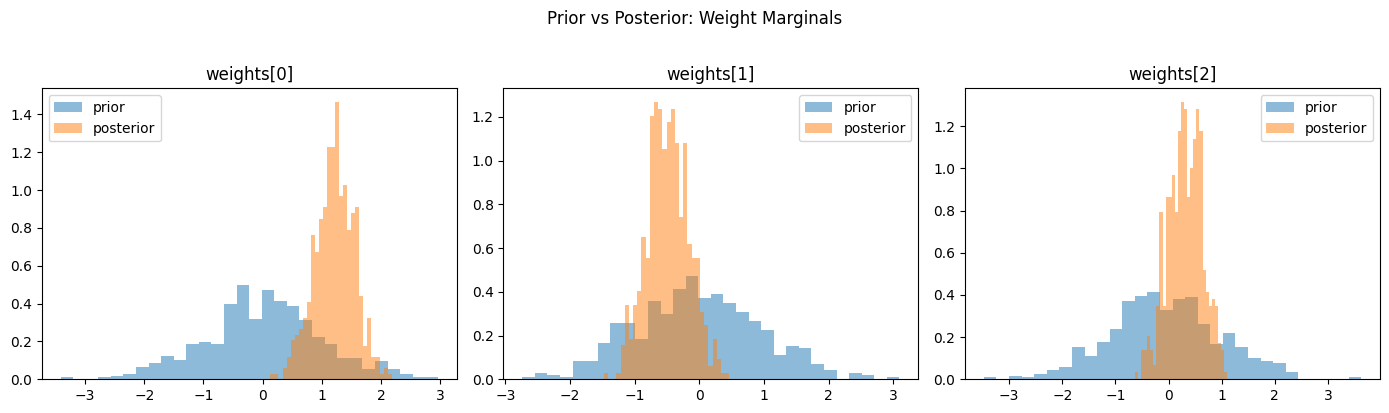

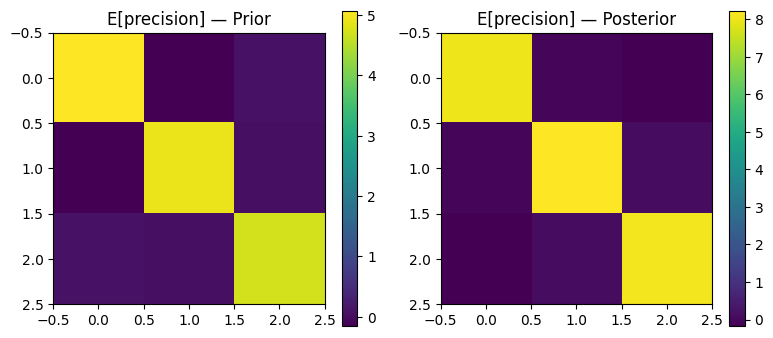

In [13]:
prior_samples = sample(prior_named, key=jax.random.PRNGKey(18), sample_shape=(500,))
post_samples = sample(posterior, key=jax.random.PRNGKey(19), sample_shape=(500,))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Weight marginals
for i, ax in enumerate(axes):
    ax.hist(prior_samples["weights"][:, i], bins=30, density=True, alpha=0.5, label="prior")
    ax.hist(post_samples["weights"][:, i], bins=30, density=True, alpha=0.5, label="posterior")
    ax.set_title(f"weights[{i}]")
    ax.legend()

plt.suptitle("Prior vs Posterior: Weight Marginals", y=1.02)
plt.tight_layout()
plt.show()

# Precision matrix: show mean matrices as heatmaps
prior_prec_mean = jnp.mean(prior_samples["precision"], axis=0)
post_prec_mean = jnp.mean(post_samples["precision"], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
im1 = ax1.imshow(prior_prec_mean, cmap="viridis")
ax1.set_title("E[precision] — Prior")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(post_prec_mean, cmap="viridis")
ax2.set_title("E[precision] — Posterior")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## FlattenedView Interop: Using Flat Algorithms with Pytree Distributions

The key use case for `as_flat_distribution()` is feeding structured distributions into algorithms that only understand flat vectors. Here we demonstrate that an algorithm operating on the flat view produces results that can be seamlessly unflattened back to the pytree structure.

In [14]:
# Simulate a "flat algorithm" that computes the MAP estimate via gradient ascent
# on the flat log-prob surface
flat_prior = prior.as_flat_distribution()

@jax.grad
def flat_log_prob_grad(x):
    return log_prob(flat_prior, x)

# Start from a flat sample
x = sample(flat_prior, key=jax.random.PRNGKey(20))
lr = 0.001
for _ in range(200):
    x = x + lr * flat_log_prob_grad(x)

# Unflatten the result back to the pytree
result = flat_prior.unflatten_sample(x)
print("MAP estimate (via gradient ascent on flat view):")
print(f"  weights:   {result['weights']}")
print(f"  precision diagonal: {jnp.diag(result['precision'])}")
print(f"\nThe flat algorithm never knew about dicts or matrices — ")
print(f"it just optimized a {flat_prior.event_shape[0]}-dimensional vector.")

MAP estimate (via gradient ascent on flat view):
  weights:   [-0.27649996  0.09839299  0.6983499 ]
  precision diagonal: [2.4121144 4.1573873 4.7395744]

The flat algorithm never knew about dicts or matrices — 
it just optimized a 12-dimensional vector.


## Summary

Key takeaways:

1. **`PyTreeArrayDistribution`** supports distributions whose samples are arbitrary pytrees (dicts, nested structures), not just single arrays.
2. **Shape semantics** generalize cleanly: `event_shapes` is a pytree of per-leaf shapes, `event_size` is the total scalar count, `batch_shape` is shared.
3. **`flatten_value` / `unflatten_value`** handle multi-leaf pytrees by raveling each leaf and concatenating. Leading `sample_shape` and `batch_shape` dimensions are preserved.
4. **`FlattenedView`** via `as_flat_distribution()` bridges the pytree and flat worlds — any algorithm written for `ArrayDistribution` works with pytree distributions through this view.
5. **Expectations** (both `expectation()` and `@monte_carlo`-decorated methods like `.mean()`) work on pytree distributions, supporting scalar-valued, array-valued, and pytree-valued output functions.
6. **Provenance tracking** works identically for pytree distributions.
7. This is the foundation for **Phase 3+**: `ProductDistribution`, `RandomMeasure`, and `RandomFunction`.